Bagging and Random Forest

In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV


sns.set()
from matplotlib import rcParams
rcParams["figure.figsize"] = 11, 8


In [7]:
data = pd.read_csv(
    "M:/accenture/ds-ml-training/ds-ai-assignments-maksym-bondar/weeks/week1/data/day.csv"
)


In [9]:
threshold = data["cnt"].median()
data["high_demand"] = (data["cnt"] > threshold).astype(int)

print("Median cnt:", threshold)
data["high_demand"].value_counts(normalize=True)


Median cnt: 4548.0


high_demand
0    0.500684
1    0.499316
Name: proportion, dtype: float64

In [10]:
categorical_columns = [
    "season",    
    "yr",        
    "mnth",     
    "holiday",   
    "weekday",   
    "workingday",
    "weathersit" 
]

drop_columns = [
    "dteday",     
    "casual",   
    "registered",
    "cnt", 
    "high_demand" 
]

numerical_columns = [
    c for c in data.columns
    if c not in categorical_columns + drop_columns
]

print("Categorical features:", categorical_columns)
print("Numerical features:", numerical_columns)


Categorical features: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
Numerical features: ['instant', 'temp', 'atemp', 'hum', 'windspeed']


In [16]:
independent_columns_names = categorical_columns + numerical_columns

In [17]:

X = data[independent_columns_names]
y = data["high_demand"]

In [18]:
independent_columns_names

['season',
 'yr',
 'mnth',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'instant',
 'temp',
 'atemp',
 'hum',
 'windspeed']

Target Balance Plot

Distribution of the target:


high_demand
0    0.500684
1    0.499316
Name: proportion, dtype: float64

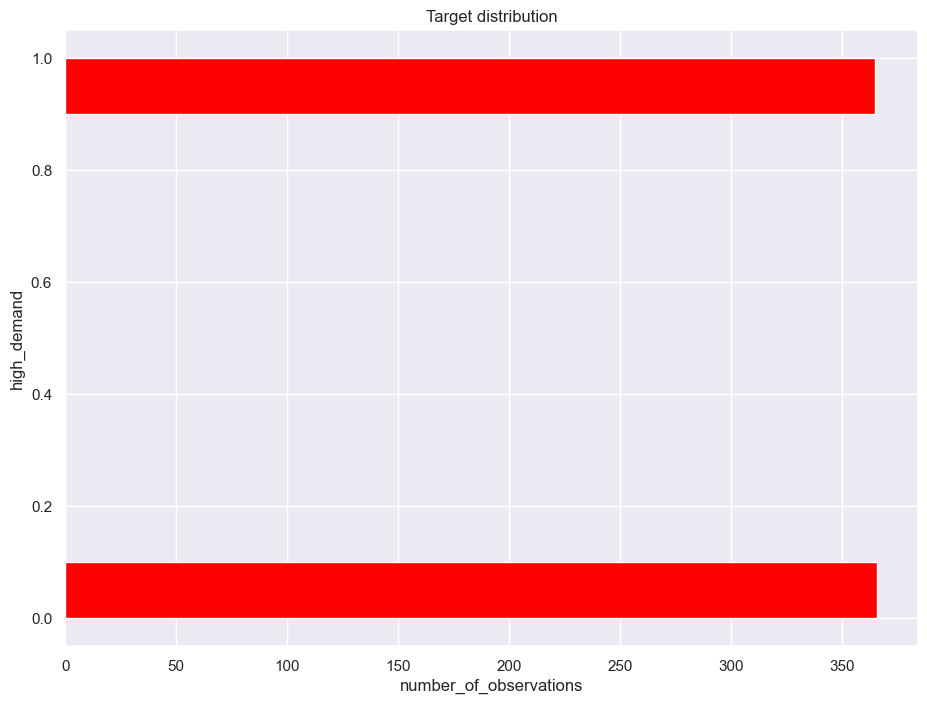

In [20]:
ax = y.hist(orientation="horizontal", color="red")
ax.set_xlabel("number_of_observations")
ax.set_ylabel("high_demand")
ax.set_title("Target distribution")

print("Distribution of the target:")
y.value_counts(normalize=True)


Bootstrapping (avg temperature of high-demand days)

In [21]:
def get_bootstrap_samples(data, n_samples):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha):
    boundaries = np.percentile(stat, [100*alpha/2, 100*(1-alpha/2)])
    return boundaries

high_temp = data[data["high_demand"] == 1]["temp"].values

np.random.seed(0)
high_temp_mean_scores = [
    np.mean(sample) for sample in get_bootstrap_samples(high_temp, 1000)
]

print("Mean interval:", stat_intervals(high_temp_mean_scores, 0.1))

Mean interval: [0.5806405  0.60341189]


Logistic Regression

In [23]:
lr = LogisticRegression(random_state=5, class_weight="balanced", max_iter=1000)

In [24]:
parameters = {"C": (0.0001, 0.001, 0.01, 0.1, 1, 10)}

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

In [26]:
grid_search = GridSearchCV(
    lr, parameters, n_jobs=-1, scoring="roc_auc", cv=skf, verbose=True
)
grid_search = grid_search.fit(X, y)

grid_search.best_estimator_
grid_search.best_params_, grid_search.best_score_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


({'C': 10}, np.float64(0.9360906412135535))

In [27]:
std_best = grid_search.cv_results_["std_test_score"][grid_search.best_index_]
std_best

np.float64(0.0240763187230198)

In [30]:
best_C = grid_search.best_params_["C"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_best = LogisticRegression(
    C=best_C, random_state=5, class_weight="balanced", max_iter=1000
)
lr_best.fit(X_scaled, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,5
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
imp_lr = pd.DataFrame({
    "feat": independent_columns_names,
    "coef": lr_best.coef_.flatten()
})
imp_lr["coef_abs"] = imp_lr["coef"].abs()
imp_lr.sort_values(by="coef_abs", ascending=False)

,feat,coef,coef_abs
1,yr,3.242001,3.242001
8,temp,2.765620,2.765620
7,instant,-1.456610,1.456610
0,season,0.993482,0.993482
9,atemp,-0.702903,0.702903
2,mnth,0.666353,0.666353
10,hum,-0.519769,0.519769
6,weathersit,-0.512044,0.512044
11,windspeed,-0.474140,0.474140
4,weekday,0.173920,0.173920


Random Forest

In [33]:
rf = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

In [34]:
parameters_rf = {
    "max_features": [1, 2, 4],
    "min_samples_leaf": [3, 5, 7, 9],
    "max_depth": [5, 10, 15],
}


In [35]:
rf_grid_search = GridSearchCV(
    rf, parameters_rf, n_jobs=-1, scoring="roc_auc", cv=skf, verbose=True
)
rf_grid_search = rf_grid_search.fit(X, y)

rf_grid_search.best_estimator_
rf_grid_search.best_score_


Fitting 5 folds for each of 36 candidates, totalling 180 fits


np.float64(0.9667743555152075)

Compare to Logistic Regression:

In [36]:
rf_grid_search.best_score_ - grid_search.best_score_


np.float64(0.030683714301654064)

Random Forest Feature Importance

In [ ]:
rf_best = rf_grid_search.best_estimator_
importances = rf_best.feature_importances_

pd.DataFrame({
    "feat": independent_columns_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)


,feat,importance
7,instant,0.301861
9,atemp,0.175866
8,temp,0.165032
1,yr,0.100719
10,hum,0.063678
0,season,0.055651
11,windspeed,0.044943
2,mnth,0.036689
6,weathersit,0.029132
4,weekday,0.021256


Bagging With Logistic Regression

In [40]:
bg = BaggingClassifier(
    LogisticRegression(class_weight="balanced", max_iter=1000),
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
)


In [42]:
parameters_bg = {
    "max_features": [2, 3, 4],
    "max_samples": [0.5, 0.7, 0.9],
    "estimator__C": [0.0001, 0.001, 0.01, 1, 10, 100],
}

r_grid_search = RandomizedSearchCV(
    bg, parameters_bg, n_jobs=-1,
    scoring="roc_auc", cv=skf,
    n_iter=20, random_state=1,
    verbose=True
)

r_grid_search = r_grid_search.fit(X, y)
r_grid_search.best_score_


Fitting 5 folds for each of 20 candidates, totalling 100 fits


np.float64(0.9355570996028868)